<div align="center" style="max-width: 800px; margin: 60px auto; padding: 90px 70px; background: #ffffff; font-family: 'Georgia', serif; text-align: center;">

<p style="color: #999; font-size: 0.75em; letter-spacing: 3px; text-transform: uppercase; margin: 0;">
Arab Youth Space Hackathon · 813 Challenge
</p>

<h1 style="color: #222; font-size: 2.6em; font-weight: 300; margin: 20px 0; letter-spacing: 1px;">
See Beyond Green
</h1>

<div style="width: 50px; height: 1px; background: #333; margin: 45px auto;"></div>

<p style="color: #666; font-size: 0.85em; letter-spacing: 2px; margin: 0;">PROOF OF CONCEPT</p>
<h2 style="color: #2a78d6; font-size: 1.6em; font-weight: 300; margin: 10px 0;">Precision Agriculture and Crop Intelligence</h2>

<div style="margin: 45px 0;">
<h3 style="color: #444; font-size: 1.3em; font-weight: 400; line-height: 1.6; margin: 0; font-style: italic;">
Plot-level crop screening and cultivated-land change<br/>
in the Souf oasis, El Oued, Algeria
</h3>
<p style="color: #888; font-size: 0.85em; margin: 14px 0 0 0;">from open Sentinel-2 imagery</p>
</div>

<div style="width: 50px; height: 1px; background: #333; margin: 45px auto;"></div>

<p style="color: #aaa; font-size: 0.7em; letter-spacing: 2px; text-transform: uppercase; margin: 0 0 15px 0;">
Team Astra
</p>
<p style="color: #333; font-size: 1em; line-height: 1.8; margin: 0;">
Beghoura Asma <span style="color: #999; font-size: 0.85em;">(Team Leader)</span><br/>
Agoudjil Heba<br/>
Kadri Marwa<br/>
Khraimech Amina<br/>
</p>

<p style="color: #777; font-size: 0.85em; line-height: 1.8; margin: 40px 0 0 0;">
National Higher School of Mathematics, Algeria<br/>
October 2026
</p>

</div>

### The problem

The Souf oasis of El Oued is one of Algeria's main potato-producing regions. Thousands of small centre pivots irrigate crops from groundwater in a hyper-arid desert, within a water system under pressure. A failing crop becomes visible on the ground only when it yellows, by which time the loss has already occurred, and no extension service can inspect thousands of plots every week.

**User:** an agricultural extension officer or farm manager.<br>
**Decision:** which plots to inspect first.

### Why it is difficult

El Oued grows potatoes on two calendars in parallel (Houben et al., 2017). The late-season crop (*arrière-saison*), grown by most farmers, is planted in August and September and harvested in December. The main-season crop is planted between January and March and harvested from May. A crop that declines in December is therefore usually being harvested, not failing. Any method that judges a plot against the area as a whole will confuse the two, and many pivots carry a second crop in the same year.

### Approach

The notebook answers six questions in sequence, using only open Sentinel-2 Level-2A imagery and no field boundaries.

1. **Where are the cultivated plots?** In a hyper-arid landscape, vegetation that turns green is, with few exceptions, cultivated, so plots are detected directly from the satellite record (Sections 6 and 7).
2. **What did each crop do over the year?** The phenology of every plot is reconstructed across a full agricultural year: emergence, decline and length of the green season (Section 8).
3. **Did its season end early?** Each crop is compared only with crops that emerged in the same weeks, and is flagged when its green season was markedly shorter than theirs. The test holds for both calendars at once (Sections 9 and 10, Figure 1).
4. **Does leaf water see further than greenness?** We test whether short-wave infrared leaf water (NDMI) declines before greenness (NDVI) and, decisively, whether it does so more on failing crops than on healthy ones (Section 11, Figure 2).
5. **How early could we have known?** Each season is replayed date by date with past observations only, to measure the warning time each signal would have given (Section 12, Figure 3).
6. **How is the oasis changing?** Cultivated land is measured season by season since 2020, to place the screening in the context of a rapidly evolving agriculture (Section 13, Figure 4).

### Reading this notebook

The notebook runs end to end in Google Colab without credentials. The main study parameters are set in Section 2, the headline numbers are collected in Section 14, and the software versions used are recorded in Section 15. The outputs are screening indicators that rank plots for human inspection, not diagnoses; their verification and limits are set out in Section 16. Full references are listed in the repository README.

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
1. Install Dependencies
</h2>
</div>

In [1]:
!pip install -q pystac-client==0.9.0 planetary-computer==1.0.0 odc-stac==0.5.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.1 MB/s eta 0:00:00


<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
2. Configuration
</h2>
</div>
The main study parameters are defined here.

In [2]:
# ---------------- study design ----------------
BBOX       = [6.903, 33.422, 7.019, 33.523]   # west, south, east, north (WGS84): Souf oasis, El Oued
START_DATE = "2022-08-01"                     # one full agricultural year, so that both crop calendars
END_DATE   = "2023-07-31"                     # are seen from emergence to harvest
MAX_CLOUD  = 20                               # maximum scene cloud cover, %
RESOLUTION = 20                               # metres
EPSG       = "EPSG:32632"                     # UTM zone 32N, correct for this longitude

# ---------------- plot detection ----------------
NDVI_FIELD_THRESHOLD = 0.30   # a pixel that reaches this at least once in the year is cultivated
N_FIELDS             = 400    # assess the N largest plots

# ---------------- phenology and the failure test ----------------
MIN_CLEAR_DATES = 20          # a plot needs this many cloud-free observations
MIN_PEAK_NDVI   = 0.25        # the plot must have grown a real crop
MIN_AMPLITUDE   = 0.15        # below this seasonal swing there is no annual crop cycle
PERENNIAL_FLOOR = 0.20        # ... and a perennial (e.g. palm grove) stays at least this green all year
COHORT_WINDOW   = 20          # crops emerging within this many days of each other form a cohort
MIN_COHORT      = 5           # a cohort needs at least this many other plots
SHORTFALL_DAYS  = 25          # flagged if green season is this many days shorter than its cohort's

# ---------------- context analysis ----------------
RUN_EXPANSION   = True
EXPANSION_YEARS = list(range(2020, 2026))     # agricultural years, labelled by harvest year
EXPANSION_RES   = 40                          # metres: enough for area accounting and far faster

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
3. Figure Style
</h2>
</div>
Colours are assigned by the job they do. Categories use three hues validated to remain distinguishable under all
common forms of colour-vision deficiency. Change maps use a diverging pair with a neutral grey midpoint. Every
category is also named in a legend or label, so no information is carried by colour alone.

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator
warnings.filterwarnings("ignore", category=RuntimeWarning)

INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
C_STABLE, C_PRIORITY, C_NORMAL = "#2a78d6", "#eb6834", "#1baf7a"   # categorical slots 1-3
C_NA = "#c3c2b7"                                                   # neutral, not a category hue
C_NDVI, C_NDMI = "#2a78d6", "#eb6834"                              # two-series lines
C_LOSS, C_GAIN, C_KEPT = "#2a78d6", "#e34948", "#898781"          # diverging poles + neutral

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "lines.linewidth": 2, "axes.axisbelow": True,
})

def map_axes(ax):
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

def scalebar(ax, extent, length_m=2000):
    x0, x1, y0, y1 = extent
    xs, ys = x0 + 0.05 * (x1 - x0), y0 + 0.05 * (y1 - y0)
    ax.add_patch(mpatches.FancyBboxPatch((xs - 0.02*(x1-x0), ys - 0.025*(y1-y0)),
                 length_m + 0.04*(x1-x0), 0.085*(y1-y0), boxstyle="round,pad=0",
                 fc=SURFACE, ec="none", alpha=0.85, zorder=5))
    ax.plot([xs, xs + length_m], [ys, ys], color=INK, lw=3, solid_capstyle="butt", zorder=6)
    ax.text(xs + length_m / 2, ys + 0.018 * (y1 - y0), f"{length_m/1000:g} km", ha="center",
            va="bottom", color=INK, fontsize=9, fontweight="bold", zorder=6)

def north_arrow(ax, extent):
    x0, x1, y0, y1 = extent
    x, y, h = x1 - 0.07 * (x1 - x0), y1 - 0.17 * (y1 - y0), 0.08 * (y1 - y0)
    ax.annotate("", xy=(x, y + h), xytext=(x, y),
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.8, mutation_scale=14))
    ax.text(x, y + h + 0.01 * (y1 - y0), "N", ha="center", va="bottom",
            color=INK, fontsize=11, fontweight="bold")

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
4. Find the Satellite Images
</h2>
</div>
We query the Microsoft Planetary Computer STAC catalogue. STAC is an index: this step only asks which images
exist. Nothing is downloaded yet.

The public catalogue limits how many requests one network address can make, and Colab machines share
addresses, so the limit can be reached even on a first run. Searches therefore wait and retry automatically.

In [4]:
import time
import pandas as pd
import pystac_client, planetary_computer
from pystac_client.exceptions import APIError

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

def search_items(datetime, attempts=6, first_wait=20):
    # search Sentinel-2 L2A over BBOX, waiting and retrying if the public rate limit is reached
    for attempt in range(attempts):
        try:
            return list(catalog.search(collections=["sentinel-2-l2a"], bbox=BBOX, datetime=datetime,
                                       query={"eo:cloud_cover": {"lt": MAX_CLOUD}}).items())
        except APIError as err:
            if "rate limit" not in str(err).lower() or attempt == attempts - 1:
                raise
            wait = first_wait * 2 ** attempt
            print(f"  catalogue rate limit reached; waiting {wait} s, then retrying "
                  f"(attempt {attempt + 2} of {attempts})")
            time.sleep(wait)

def offset_for(item):
    # From processing baseline 04.00 (25 Jan 2022) ESA stores L2A reflectance as DN = R x 10000 + 1000,
    # and Planetary Computer serves those numbers unchanged. Older baselines have no offset.
    b = item.properties.get("s2:processing_baseline")
    try:
        return 1000 if float(b) >= 4.0 else 0
    except (TypeError, ValueError):
        return 1000 if item.datetime >= pd.Timestamp("2022-01-25", tz="UTC") else 0

found = search_items(f"{START_DATE}/{END_DATE}")
items = [it for it in found if offset_for(it) == 1000]       # one consistent offset for the main analysis
baselines = sorted({str(it.properties.get("s2:processing_baseline", "unknown")) for it in items})
print(f"{len(found)} scenes found, {len(items)} kept (all with the +1000 offset); "
      f"processing baselines: {baselines}")

503 scenes found, 503 kept (all with the +1000 offset); processing baselines: ['04.00', '05.09', '05.10']


<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
5. Load the Data and Compute the Indices
</h2>
</div>
Three quality controls are applied before any interpretation.

**Cloud screening.** The SCL band supplied with every Sentinel-2 L2A scene labels each pixel. We discard
no-data, saturated, dark-area, shadow, cloud, cirrus and snow classes. A cloud otherwise reads like dead vegetation.

**Reflectance validation.** From processing baseline 04.00 (January 2022), Level-2A digital numbers carry an
offset: `DN = reflectance x 10000 + 1000`. After removing it, a few very dark pixels fall below zero. Those values
are not physical, and when `NIR + Red` approaches zero the NDVI ratio diverges. We keep only reflectance in (0, 1.2).

**Index range check.** NDVI and NDMI are bounded in [-1, 1] by construction. Anything outside is discarded, and
the cell prints the final ranges as proof.

In [5]:
from odc.stac import load

ds = load(items, bands=["B02", "B03", "B04", "B08", "B11", "SCL"], bbox=BBOX,
          resolution=RESOLUTION, crs=EPSG, groupby="solar_day", pool=4)
print("loaded:", dict(ds.sizes))

def reflectance(band, offset=1000):
    a = (ds[band].astype("float32") - offset) / 10000
    return a.where((a > 0) & (a < 1.2))

BAD_SCL = [0, 1, 2, 3, 8, 9, 10, 11]
clear = ~ds.SCL.isin(BAD_SCL)

blue, green = reflectance("B02").where(clear), reflectance("B03").where(clear)
red, nir, swir = reflectance("B04").where(clear), reflectance("B08").where(clear), reflectance("B11").where(clear)

ndvi = (nir - red) / (nir + red)          # canopy greenness
ndmi = (nir - swir) / (nir + swir)        # leaf water content
ndvi = ndvi.where((ndvi > -1) & (ndvi < 1))
ndmi = ndmi.where((ndmi > -1) & (ndmi < 1))

print(f"NDVI range {float(ndvi.min()):.3f} to {float(ndvi.max()):.3f}   (must lie within -1 to 1)")
print(f"NDMI range {float(ndmi.min()):.3f} to {float(ndmi.max()):.3f}")

rgb = np.dstack([red.median("time").values, green.median("time").values, blue.median("time").values])
lo, hi = np.nanpercentile(rgb, [2, 98])
rgb = np.nan_to_num(np.clip((rgb - lo) / (hi - lo), 0, 1) ** 0.85, nan=1.0)
gray = rgb @ np.array([0.299, 0.587, 0.114])
del blue, green

half = RESOLUTION / 2
EXTENT = [float(ds.x.min()) - half, float(ds.x.max()) + half,
          float(ds.y.min()) - half, float(ds.y.max()) + half]
ORIGIN = "upper" if ds.y.values[0] > ds.y.values[-1] else "lower"

/usr/local/lib/python3.13/dist-packages/rasterio/warp.py:390: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


loaded: {'y': 571, 'x': 551, 'time': 116}
NDVI range -0.998 to 1.000   (must lie within -1 to 1)
NDMI range -0.990 to 0.725


<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
6. Detect the Cultivated Plots
</h2>
</div>
El Oued receives under 100 mm of rain a year and carries no natural vegetation, so any pixel that turns green at
any point in the agricultural year is irrigated land. We take the yearly maximum NDVI, threshold it, and label
connected groups of pixels. Each group is one plot. This replaces manual digitising, which would be impractical
at this plot density, and it captures plots of both crop calendars.

In [6]:
from scipy import ndimage

ndvi_max = ndvi.max("time").values
cultivated = ndvi_max > NDVI_FIELD_THRESHOLD

labels, n_found = ndimage.label(cultivated)
sizes = ndimage.sum(cultivated, labels, range(1, n_found + 1))
field_ids = (np.argsort(sizes)[::-1][:N_FIELDS] + 1).astype(int)

kept = sizes[field_ids - 1]
print(f"{n_found:,} plots detected; assessing the {len(field_ids)} largest "
      f"({kept.min()*RESOLUTION**2/1e4:.2f} to {kept.max()*RESOLUTION**2/1e4:.1f} ha)")

3,050 plots detected; assessing the 400 largest (1.76 to 84.2 ha)


<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
7. Per-Plot Time Series
</h2>
</div>
A farm manager acts on whole plots, not pixels, so each index is averaged inside each plot for each date.
Cloud-masked pixels are excluded from the average rather than counted as zero.

In [7]:
def plot_means(a2d):
    ok = ~np.isnan(a2d)
    total = ndimage.sum(np.nan_to_num(a2d), labels, field_ids)
    count = ndimage.sum(ok, labels, field_ids)
    return np.where(count > 0, total / np.maximum(count, 1), np.nan)

ndvi_vals, ndmi_vals = ndvi.values, ndmi.values
dates = [str(d)[:10] for d in ds.time.values]

records = []
for i, date in enumerate(dates):
    a, b = plot_means(ndvi_vals[i]), plot_means(ndmi_vals[i])
    records += [{"field_id": int(f), "date": date, "ndvi": a[j], "ndmi": b[j]}
                for j, f in enumerate(field_ids)]

timeseries = pd.DataFrame(records)
timeseries.to_csv("s2_timeseries.csv", index=False)
print(f"{len(timeseries):,} rows ({len(field_ids)} plots x {len(dates)} dates); "
      f"cloud-free observations {timeseries.ndvi.notna().mean():.1%}")

46,400 rows (400 plots x 116 dates); cloud-free observations 47.4%


<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
8. Phenology of Every Plot
</h2>
</div>
For each plot we smooth its clear observations lightly (a three-point running median), scale the curve to its own
seasonal range, and find:

- **emergence (green-up):** the last date before the peak at which the crop crossed half of its range on the way up;
- **decline:** the first date after the peak at which it fell below half of its range;
- **green-season length:** decline minus emergence.

Crossings are interpolated between observations. A plot with almost no seasonal swing (below `MIN_AMPLITUDE`) that
nevertheless stays green all year (its 10th-percentile NDVI is at least `PERENNIAL_FLOOR`) is classed as
**perennial**: date palm groves behave like this. A plot with almost no swing that is *not* green all year is bare or
a crop that never established; it is not called perennial, because that would hide a failure behind a reassuring label. Plots whose cycle
is not complete inside the year cannot be judged. Where a pivot is cropped twice in the year, the cycle containing
the yearly peak is analysed.

In [8]:
raw_ndvi = timeseries.pivot(index="field_id", columns="date", values="ndvi")
raw_ndmi = timeseries.pivot(index="field_id", columns="date", values="ndmi")
DAY0 = pd.Timestamp(START_DATE)
obs_days = np.array([(pd.Timestamp(d) - DAY0).days for d in raw_ndvi.columns], dtype=float)
to_date = lambda days: DAY0 + pd.to_timedelta(np.asarray(days, dtype=float), unit="D")

def clean(row, causal=False):
    # clear observations only, lightly smoothed; causal=True uses past values only
    ok = row.notna().values
    d, v = obs_days[ok], row.values[ok].astype(float)
    return d, pd.Series(v).rolling(3, center=not causal, min_periods=1).median().values

def scaled(v):
    lo, hi = np.nanmin(v), np.nanmax(v)
    return (v - lo) / (hi - lo) if hi - lo > 1e-6 else np.full_like(v, np.nan)

def crossing(d, z, i0, i1, frac=0.5):
    x0, x1, y0, y1 = d[i0], d[i1], z[i0], z[i1]
    return x1 if y1 == y0 else x0 + (frac - y0) * (x1 - x0) / (y1 - y0)

def phenology(row, frac=0.5):
    d, s = clean(row)
    out = {"n_obs": len(s), "peak": np.nan, "floor": np.nan, "amplitude": np.nan,
           "greenup": np.nan, "decline": np.nan}
    if len(s) < 3:
        return out
    out["peak"], out["amplitude"] = float(np.nanmax(s)), float(np.nanmax(s) - np.nanmin(s))
    out["floor"] = float(np.nanpercentile(s, 10))
    z = scaled(s)
    if np.isnan(z).all():
        return out
    pk = int(np.nanargmax(z))
    before, after = np.where(z[:pk] < frac)[0], np.where(z[pk:] < frac)[0]
    if before.size:
        i = int(before[-1]); out["greenup"] = crossing(d, z, i, i + 1, frac)
    if after.size:
        j = pk + int(after[0]); out["decline"] = crossing(d, z, j - 1, j, frac)
    return out

phen = pd.DataFrame([phenology(raw_ndvi.loc[f]) for f in raw_ndvi.index], index=raw_ndvi.index)
phen["season_days"] = phen.decline - phen.greenup

sparse     = phen.n_obs < MIN_CLEAR_DATES
perennial  = ~sparse & (phen.amplitude < MIN_AMPLITUDE) & (phen.floor >= PERENNIAL_FLOOR)
no_crop    = ~sparse & ~perennial & ((phen.peak < MIN_PEAK_NDVI) | (phen.amplitude < MIN_AMPLITUDE))
incomplete = ~sparse & ~perennial & ~no_crop & (phen.greenup.isna() | phen.decline.isna())
full_cycle = ~(sparse | perennial | no_crop | incomplete)

print(f"full crop cycle observed: {int(full_cycle.sum())}   perennial: {int(perennial.sum())}   "
      f"incomplete cycle: {int(incomplete.sum())}   too few clear dates: {int(sparse.sum())}   "
      f"no real crop: {int(no_crop.sum())}")

full crop cycle observed: 380   perennial: 6   incomplete cycle: 12   too few clear dates: 0   no real crop: 2


<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
9. Did the Green Season End Early?
</h2>
</div>
Two crops that emerged in the same weeks, in the same oasis, under the same weather, should stay green for
roughly the same length of time. For every plot with a complete cycle we form its **cohort**: all other plots that
emerged within `COHORT_WINDOW` days of it. A plot is flagged as a **priority** for inspection when its green season
was at least `SHORTFALL_DAYS` shorter than the median of its cohort.

Because the comparison is made within a cohort, a December harvest of the late-season crop is compared with other
late-season crops, and a May harvest of the main-season crop with other main-season crops. The two calendars no
longer contaminate each other.

In [9]:
phen["cohort_season_days"], phen["cohort_size"] = np.nan, 0
ids = phen.index[full_cycle]
g, L = phen.loc[ids, "greenup"].values, phen.loc[ids, "season_days"].values
cohort_len, cohort_n = [], []
for k in range(len(ids)):
    peers = np.abs(g - g[k]) <= COHORT_WINDOW
    peers[k] = False
    cohort_n.append(int(peers.sum()))
    cohort_len.append(float(np.median(L[peers])) if peers.sum() >= MIN_COHORT else np.nan)
phen.loc[ids, "cohort_season_days"] = cohort_len
phen.loc[ids, "cohort_size"] = cohort_n
phen["shortfall_days"] = phen.cohort_season_days - phen.season_days
phen["priority"] = full_cycle & (phen.shortfall_days >= SHORTFALL_DAYS)

CATS = ["Perennial or stable (e.g. palm groves)", "Priority: green season ended early",
        "Normal crop cycle", "Not assessable"]
CAT_COLOURS = [C_STABLE, C_PRIORITY, C_NORMAL, C_NA]

category = pd.Series(CATS[3], index=phen.index)
category[perennial] = CATS[0]
category[full_cycle & phen.cohort_season_days.notna()] = CATS[2]
category[phen.priority] = CATS[1]
assessed_ok = category.isin([CATS[1], CATS[2]])

out = phen.join(category.rename("category"))
for c in ("greenup", "decline"):
    out[c + "_date"] = [str(t.date()) if pd.notna(t) else "" for t in to_date(out[c])]
out.sort_values(["priority", "shortfall_days"], ascending=False).to_csv("fields_ranked.csv")
print(category.value_counts().reindex(CATS, fill_value=0).to_string())

Perennial or stable (e.g. palm groves)      6
Priority: green season ended early         23
Normal crop cycle                         356
Not assessable                             15


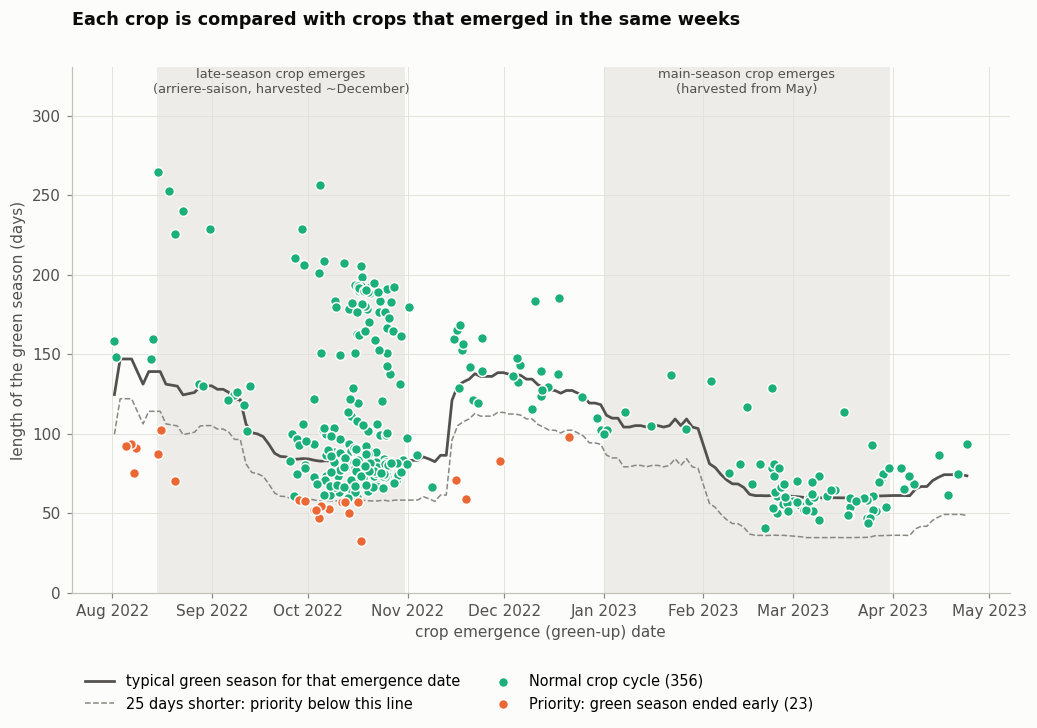

In [10]:
# ---------------- the decision rule, shown ----------------
F = phen[assessed_ok]
fig, ax = plt.subplots(figsize=(11, 6.2))

# agronomic calendar of El Oued, for orientation (not used in the computation)
Y0 = DAY0.year
for start, end, label in ((f"{Y0}-08-15", f"{Y0}-10-31", "late-season crop emerges\n(arriere-saison, harvested ~December)"),
                          (f"{Y0+1}-01-01", f"{Y0+1}-03-31", "main-season crop emerges\n(harvested from May)")):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=GRID, alpha=0.55, lw=0, zorder=0)
    ax.text(pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2, 1.0, label,
            transform=ax.get_xaxis_transform(), ha="center", va="top", color=INK_2, fontsize=8.5)

grid_g = np.linspace(F.greenup.min(), F.greenup.max(), 150) if len(F) else np.array([])
med = np.array([np.median(F.season_days[np.abs(F.greenup - gg) <= COHORT_WINDOW])
                if (np.abs(F.greenup - gg) <= COHORT_WINDOW).sum() >= MIN_COHORT else np.nan for gg in grid_g])
ax.plot(to_date(grid_g), med, color=INK_2, lw=1.8, label="typical green season for that emergence date")
ax.plot(to_date(grid_g), med - SHORTFALL_DAYS, color=MUTED, lw=1, ls="--",
        label=f"{SHORTFALL_DAYS} days shorter: priority below this line")
for name, col in ((CATS[2], C_NORMAL), (CATS[1], C_PRIORITY)):
    sel = F[category[F.index] == name]
    ax.scatter(to_date(sel.greenup), sel.season_days, s=42, color=col, edgecolor=SURFACE,
               linewidth=1, label=f"{name} ({len(sel)})", zorder=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylim(0, max(F.season_days.max() * 1.25, 60) if len(F) else 200)
ax.set_xlabel("crop emergence (green-up) date")
ax.set_ylabel("length of the green season (days)")
ax.set_title("Each crop is compared with crops that emerged in the same weeks", pad=28)
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.13), ncol=2, fontsize=9.5)
fig.savefig("fig_decision_rule.png"); plt.show()

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
10. Figure 1: Where to Inspect
</h2>
</div>
Three views of the same area: what the eye sees, what the satellite sees, and what the farm manager needs to act on.

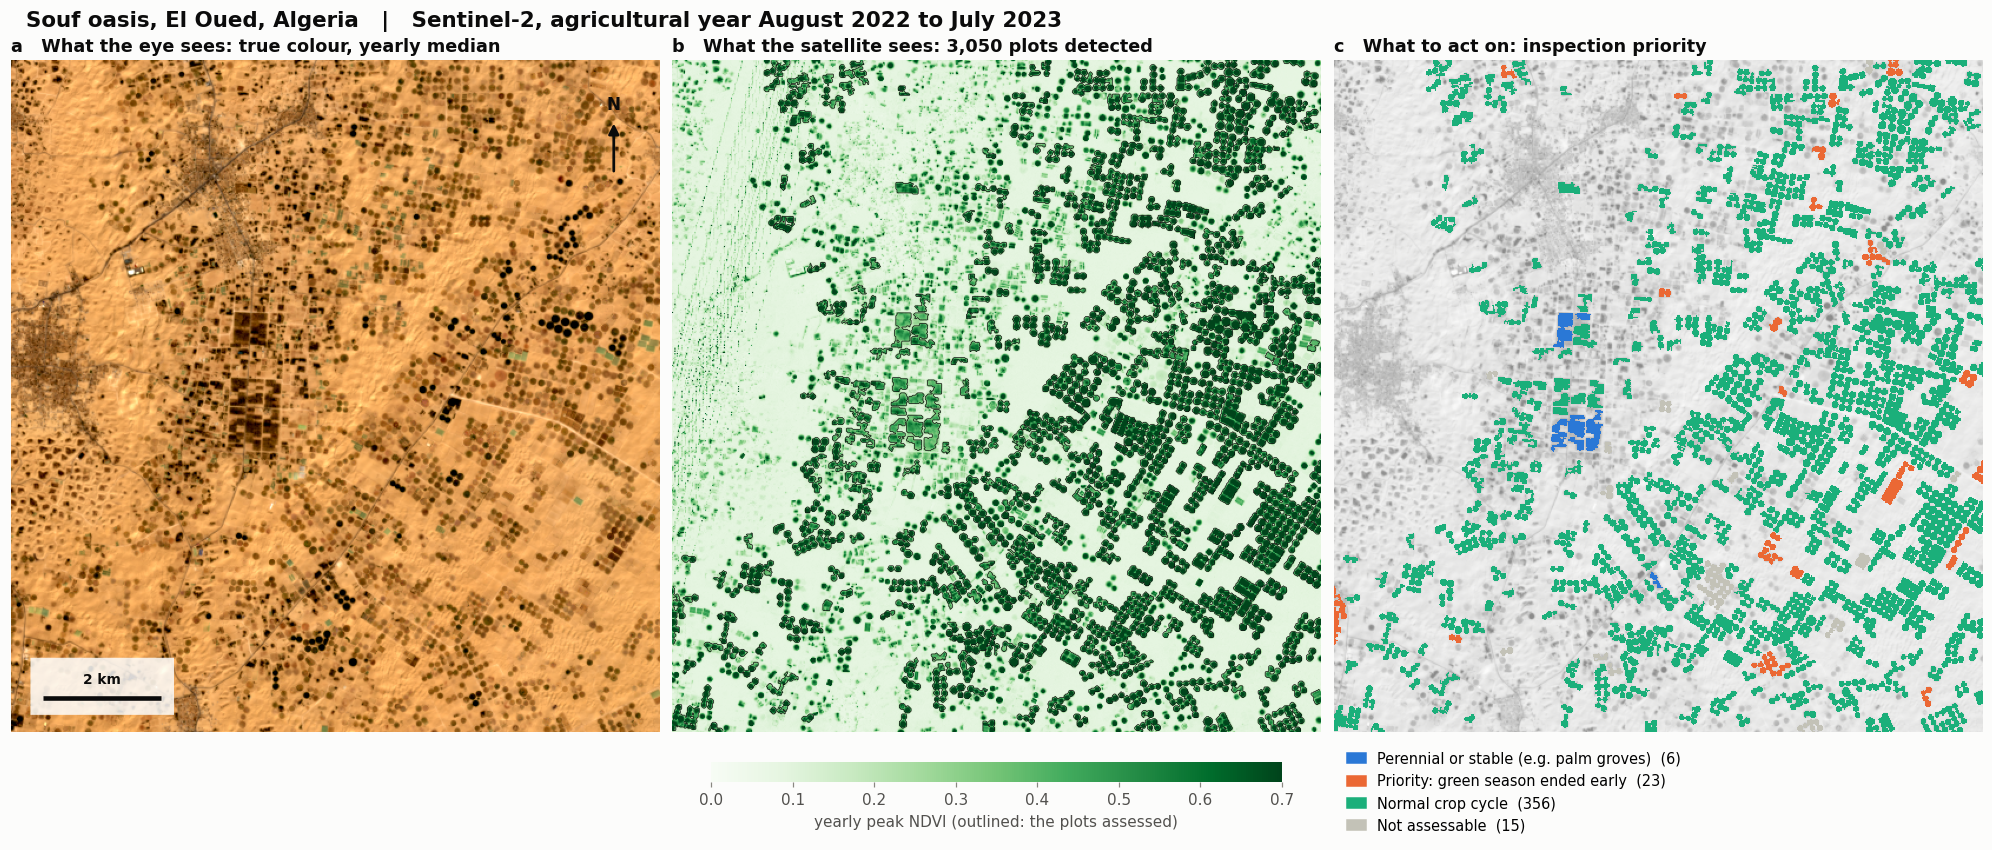

In [11]:
lut = np.full(labels.max() + 1, np.nan)
for fid, c in category.items():
    lut[fid] = CATS.index(c)
lut[0] = np.nan
cat_map = lut[labels]
assessed = np.isin(labels, category.index).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 7.2), constrained_layout=True)

ax = axes[0]
ax.imshow(rgb, extent=EXTENT, origin=ORIGIN)
ax.set_title("a   What the eye sees: true colour, yearly median")
scalebar(ax, EXTENT); north_arrow(ax, EXTENT)

ax = axes[1]
im = ax.imshow(ndvi_max, extent=EXTENT, origin=ORIGIN, cmap="Greens", vmin=0, vmax=0.7)
ax.contour(assessed, levels=[0.5], colors=INK, linewidths=0.45, extent=EXTENT, origin=ORIGIN)
ax.set_title(f"b   What the satellite sees: {n_found:,} plots detected")
cb = fig.colorbar(im, cax=ax.inset_axes([0.06, -0.075, 0.88, 0.03]), orientation="horizontal")
cb.set_label("yearly peak NDVI (outlined: the plots assessed)", color=INK_2)
cb.outline.set_visible(False)

ax = axes[2]
ax.imshow(gray, extent=EXTENT, origin=ORIGIN, cmap="Greys_r", vmin=0, vmax=1, alpha=0.45)
ax.imshow(cat_map, extent=EXTENT, origin=ORIGIN, cmap=ListedColormap(CAT_COLOURS),
          vmin=-0.5, vmax=len(CATS) - 0.5, interpolation="nearest")
ax.set_title("c   What to act on: inspection priority")
ax.legend(handles=[mpatches.Patch(color=col, label=f"{name}  ({int((category == name).sum())})")
                   for name, col in zip(CATS, CAT_COLOURS)],
          loc="upper left", bbox_to_anchor=(0, -0.01), fontsize=9.5, handlelength=1.3)

for a in axes:
    map_axes(a)
fig.suptitle("Souf oasis, El Oued, Algeria   |   Sentinel-2, agricultural year August 2022 to July 2023",
             x=0.01, y=1.04, ha="left", fontsize=14, fontweight="bold", color=INK)
fig.savefig("fig1_inspection_priority.png"); plt.show()

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
11. Figure 2: Seeing Beyond Green
</h2>
</div>

NDVI measures greenness. A plant can lose water before it loses chlorophyll, and leaf water is visible in the
short-wave infrared through NDMI. For every assessed plot we find the date on which each index fell below half of
its seasonal range after its peak. The **lead** is the NDVI decline date minus the NDMI decline date: positive
means leaf water fell first.

A lead on its own is not enough. NDVI saturates over dense canopy, so NDMI can appear to fall first on *any*
senescing crop for purely optical reasons. The real test is whether the lead is **larger on failing crops than on
normal ones**. We therefore compare the two groups with a one-sided Mann-Whitney test, alongside a Wilcoxon test
of the overall lead against zero. Leads larger than 45 days are excluded as belonging to different crop cycles.

One more trap: if failing crops decline more slowly than harvested ones, the same small optical offset between the
two indices turns into more days. We therefore repeat the group comparison with the lead divided by how long each
crop's greenness took to decline, and only claim a stress signal if the difference survives that correction.

plots analysed: 340 (21 priority), 38 excluded as mismatched cycles
median lead, all plots: +3.1 days   leaf water first in 80%   Wilcoxon p = 2.09e-27
median lead, priority: +0.5 days   normal: +3.3 days   Mann-Whitney p = 1
greenness decline lasts 32 days on priority plots, 51 on normal ones; lead scaled by decline speed: Mann-Whitney p = 0.999


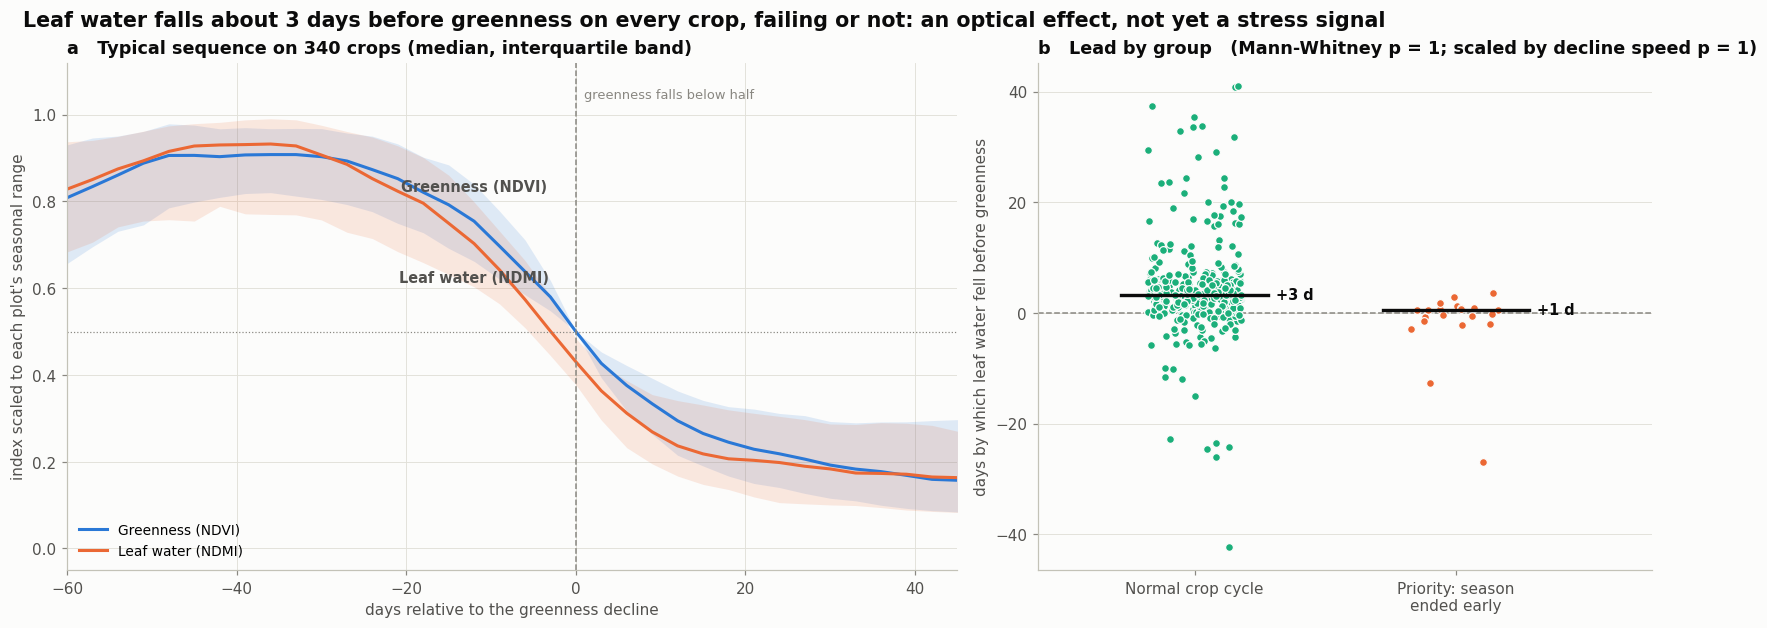

In [12]:
from scipy.stats import wilcoxon, mannwhitneyu

ndmi_decline = pd.Series({f: phenology(raw_ndmi.loc[f])["decline"] for f in phen.index[assessed_ok]})
lead = pd.DataFrame({"ndvi_decline": phen.loc[assessed_ok, "decline"], "ndmi_decline": ndmi_decline,
                     "priority": phen.loc[assessed_ok, "priority"]}).dropna(subset=["ndvi_decline", "ndmi_decline"])
lead["lead_days"] = lead.ndvi_decline - lead.ndmi_decline
n_mismatch = int((lead.lead_days.abs() > 45).sum())
lead = lead[lead.lead_days.abs() <= 45].copy()

def decline_duration(row, hi=0.8, lo=0.2):
    # days taken by greenness to fall from 80% to 20% of its seasonal range after the peak
    d, s = clean(row)
    z = scaled(s)
    if np.isnan(z).all():
        return np.nan
    pk = int(np.nanargmax(z))
    a, b = np.where(z[pk:] < hi)[0], np.where(z[pk:] < lo)[0]
    if not a.size or not b.size:
        return np.nan
    ja, jb = pk + int(a[0]), pk + int(b[0])
    dur = crossing(d, z, jb - 1, jb, lo) - crossing(d, z, ja - 1, ja, hi)
    return dur if dur > 0 else np.nan

lead["decline_days"] = [decline_duration(raw_ndvi.loc[f]) for f in lead.index]
lead["lead_relative"] = lead.lead_days / lead.decline_days

def safe(fn, *a, **k):
    try:
        return float(fn(*a, **k).pvalue)
    except ValueError:
        return float("nan")

LEAD_ALL = float(lead.lead_days.median()) if len(lead) else float("nan")
LEAD_PRI = float(lead.lead_days[lead.priority].median()) if lead.priority.any() else float("nan")
LEAD_NOR = float(lead.lead_days[~lead.priority].median()) if (~lead.priority).any() else float("nan")
LEAD_SHARE = float((lead.lead_days > 0).mean()) if len(lead) else float("nan")
P_ALL = safe(wilcoxon, lead.lead_days) if len(lead) >= 5 else float("nan")
P_GROUP = (safe(mannwhitneyu, lead.lead_days[lead.priority], lead.lead_days[~lead.priority], alternative="greater")
           if lead.priority.sum() >= 3 and (~lead.priority).sum() >= 3 else float("nan"))

rel_ok = lead.dropna(subset=["lead_relative"])
P_GROUP_REL = (safe(mannwhitneyu, rel_ok.lead_relative[rel_ok.priority], rel_ok.lead_relative[~rel_ok.priority],
                    alternative="greater")
               if rel_ok.priority.sum() >= 3 and (~rel_ok.priority).sum() >= 3 else float("nan"))
DECL_PRI = float(lead.decline_days[lead.priority].median()) if lead.priority.any() else float("nan")
DECL_NOR = float(lead.decline_days[~lead.priority].median()) if (~lead.priority).any() else float("nan")

print(f"plots analysed: {len(lead)} ({int(lead.priority.sum())} priority), {n_mismatch} excluded as mismatched cycles")
print(f"median lead, all plots: {LEAD_ALL:+.1f} days   leaf water first in {LEAD_SHARE:.0%}   Wilcoxon p = {P_ALL:.3g}")
print(f"median lead, priority: {LEAD_PRI:+.1f} days   normal: {LEAD_NOR:+.1f} days   Mann-Whitney p = {P_GROUP:.3g}")
print(f"greenness decline lasts {DECL_PRI:.0f} days on priority plots, {DECL_NOR:.0f} on normal ones; "
      f"lead scaled by decline speed: Mann-Whitney p = {P_GROUP_REL:.3g}")

if P_GROUP < 0.05 and LEAD_PRI > LEAD_NOR and P_GROUP_REL < 0.05:
    headline = (f"On crops whose season ends early, leaf water falls {LEAD_PRI:.0f} days before greenness, "
                f"against {LEAD_NOR:.0f} on normal crops")
elif P_GROUP < 0.05 and LEAD_PRI > LEAD_NOR:
    headline = (f"Leaf water leads greenness more on failing crops ({LEAD_PRI:.0f} against {LEAD_NOR:.0f} days), "
                f"but their slower decline explains part of the gap")
elif P_ALL < 0.05 and LEAD_ALL > 0:
    headline = (f"Leaf water falls about {LEAD_ALL:.0f} days before greenness on every crop, "
                f"failing or not: an optical effect, not yet a stress signal")
else:
    headline = "At 20 m, leaf water gives no consistent early signal over greenness"

GRID_DAYS = np.arange(-60, 46, 3)
curves = {"ndvi": [], "ndmi": []}
for fid, r in lead.iterrows():
    for key, raw in (("ndvi", raw_ndvi), ("ndmi", raw_ndmi)):
        d, s = clean(raw.loc[fid])
        curves[key].append(np.interp(GRID_DAYS, d - r.ndvi_decline, scaled(s), left=np.nan, right=np.nan))

if len(lead) >= 5:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.6), constrained_layout=True,
                                   gridspec_kw={"width_ratios": [1.45, 1]})
    med_curves = {}
    for key, col, name in (("ndvi", C_NDVI, "Greenness (NDVI)"), ("ndmi", C_NDMI, "Leaf water (NDMI)")):
        arr = np.array(curves[key])
        m = np.nanmedian(arr, axis=0); q1, q3 = np.nanpercentile(arr, [25, 75], axis=0)
        med_curves[key] = m
        ax1.fill_between(GRID_DAYS, q1, q3, color=col, alpha=0.14, lw=0)
        ax1.plot(GRID_DAYS, m, color=col, label=name)
    k = int(np.argmin(np.abs(GRID_DAYS + 12)))
    upper = "ndvi" if med_curves["ndvi"][k] >= med_curves["ndmi"][k] else "ndmi"
    for key, name in (("ndvi", "Greenness (NDVI)"), ("ndmi", "Leaf water (NDMI)")):
        ax1.text(GRID_DAYS[k], med_curves[key][k] + (0.07 if key == upper else -0.09), name,
                 color=INK_2, fontsize=9.5, ha="center", fontweight="bold")
    ax1.axvline(0, color=MUTED, lw=1, ls="--"); ax1.axhline(0.5, color=MUTED, lw=0.8, ls=":")
    ax1.text(1, 1.03, "greenness falls below half", color=MUTED, fontsize=8.5, va="bottom")
    ax1.set_xlim(GRID_DAYS[0], GRID_DAYS[-1]); ax1.set_ylim(-0.05, 1.12)
    ax1.set_xlabel("days relative to the greenness decline")
    ax1.set_ylabel("index scaled to each plot's seasonal range")
    ax1.set_title(f"a   Typical sequence on {len(lead)} crops (median, interquartile band)")
    ax1.legend(loc="lower left", fontsize=9)

    rng = np.random.default_rng(0)
    groups = ((0, "Normal crop cycle", ~lead.priority, C_NORMAL),
              (1, "Priority: season\nended early", lead.priority, C_PRIORITY))
    for x, name, sel, col in groups:
        v = lead.lead_days[sel].values
        ax2.scatter(x + rng.uniform(-0.18, 0.18, len(v)), v, s=26, color=col, edgecolor=SURFACE,
                    linewidth=0.8, zorder=3)
        if len(v):
            ax2.plot([x - 0.28, x + 0.28], [np.median(v)] * 2, color=INK, lw=2.2, zorder=4)
            ax2.text(x + 0.31, np.median(v), f"{np.median(v):+.0f} d", va="center", color=INK,
                     fontsize=9.5, fontweight="bold")
    ax2.axhline(0, color=MUTED, lw=1, ls="--")
    ax2.set_xticks([0, 1]); ax2.set_xticklabels([n for _, n, _, _ in groups])
    ax2.set_xlim(-0.6, 1.75); ax2.grid(axis="x", visible=False)
    ax2.set_ylabel("days by which leaf water fell before greenness")
    ax2.set_title(f"b   Lead by group   (Mann-Whitney p = {P_GROUP:.2g}; "
                  f"scaled by decline speed p = {P_GROUP_REL:.2g})")
    fig.suptitle(headline, x=0.01, ha="left", fontsize=13.5, fontweight="bold", color=INK)
    fig.savefig("fig2_beyond_green.png"); plt.show()
else:
    print("Too few plots for a lead-time analysis; Figure 2 skipped.")

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
12. Figure 3: How Early Could We Have Known?
</h2>
</div>
A warning is only useful if it arrives in time to act. We **replay each crop's season** date by date, using only
observations available up to that date (trailing smoothing, no future values). An alarm is raised when an index
has fallen more than half of its typical seasonal range below its running peak, *and* the crop has been green for
less time than its cohort normally is, minus `SHORTFALL_DAYS`. That second condition is what makes the alarm mean
"ending too early" rather than "being harvested".

Two warning rules are compared: **greenness only** (NDVI) and **beyond green** (NDVI *or* NDMI). We measure, for
the priority plots, how long before their visible greenness decline each rule would have raised the alarm, and we
count the alarms each rule would have raised on plots that turned out normal or perennial.

The emergence date and the cohort's typical season length are taken from the full year. Emergence happens weeks
before any decline, so this uses no information from after the alarm in practice; it is stated here for
transparency.

priority plots: 23   normal and perennial plots watched: 362
caught before the end: greenness only 48%, beyond green 52%
median alarm relative to the visible decline: greenness only 6 days after, beyond green 6 days after
median extra warning from leaf water: 0 days
alarms on normal or perennial plots: greenness only 1, beyond green 1 (of 362)


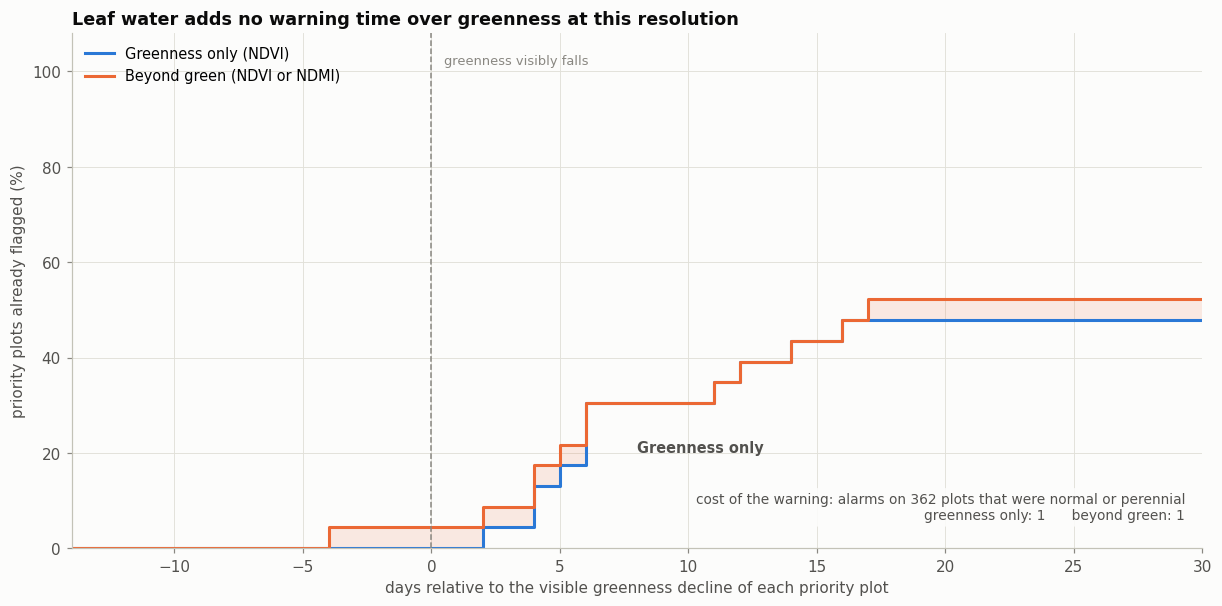

In [13]:
AMP = {"ndvi": float(np.nanmedian(phen.loc[assessed_ok, "amplitude"])),
       "ndmi": float(np.nanmedian([np.ptp(clean(raw_ndmi.loc[f])[1]) for f in phen.index[assessed_ok]]))}

def first_alarm(fid, raw, key, greenup, expected):
    d, s = clean(raw.loc[fid], causal=True)
    if np.isfinite(greenup):
        # judge this crop only: its running peak starts at its own emergence, so an earlier crop
        # on the same pivot (double cropping) cannot trigger an alarm on the next one
        keep = d >= greenup
        d, s = d[keep], s[keep]
    if len(s) < 4:
        return np.nan
    running_peak = np.maximum.accumulate(s)
    fire = (running_peak - s) > 0.5 * AMP[key]
    if np.isfinite(greenup) and np.isfinite(expected):
        fire &= (d - greenup) < expected - SHORTFALL_DAYS
    fire[:3] = False
    hit = np.where(fire)[0]
    return d[hit[0]] if hit.size else np.nan

watch = phen.index[assessed_ok | perennial]
alarms = pd.DataFrame(index=watch, columns=["ndvi", "ndmi"], dtype=float)
for f in watch:
    gu, ex = phen.at[f, "greenup"], phen.at[f, "cohort_season_days"]
    alarms.at[f, "ndvi"] = first_alarm(f, raw_ndvi, "ndvi", gu, ex)
    alarms.at[f, "ndmi"] = first_alarm(f, raw_ndmi, "ndmi", gu, ex)
alarms["greenness_only"] = alarms.ndvi
alarms["beyond_green"] = np.fmin(alarms.ndvi, alarms.ndmi)

pri = phen.index[phen.priority]
non = phen.index[(category == CATS[2]) | (category == CATS[0])]
rel = alarms.loc[pri, ["greenness_only", "beyond_green"]].sub(phen.loc[pri, "decline"], axis=0)

REL_DAYS = np.arange(-40, 31, 1)
share = {r: np.array([(rel[r].values <= t).sum() / max(len(rel), 1) for t in REL_DAYS]) for r in rel.columns}
both = rel.dropna()
GAIN_DAYS = float((both.greenness_only - both.beyond_green).median()) if len(both) else float("nan")
LEAD_G = float(-rel.greenness_only.median()) if len(rel) else float("nan")
LEAD_B = float(-rel.beyond_green.median()) if len(rel) else float("nan")
FA_G = int(alarms.loc[non, "greenness_only"].notna().sum())
FA_B = int(alarms.loc[non, "beyond_green"].notna().sum())
CAUGHT_G = float(rel.greenness_only.notna().mean()) if len(rel) else float("nan")
CAUGHT_B = float(rel.beyond_green.notna().mean()) if len(rel) else float("nan")

print(f"priority plots: {len(pri)}   normal and perennial plots watched: {len(non)}")
print(f"caught before the end: greenness only {CAUGHT_G:.0%}, beyond green {CAUGHT_B:.0%}")
when = lambda x: f"{abs(x):.0f} days {'before' if x > 0 else 'after'}"
print(f"median alarm relative to the visible decline: greenness only {when(LEAD_G)}, "
      f"beyond green {when(LEAD_B)}")
print(f"median extra warning from leaf water: {GAIN_DAYS:.0f} days")
print(f"alarms on normal or perennial plots: greenness only {FA_G}, beyond green {FA_B} (of {len(non)})")

if len(pri):
    fig, ax = plt.subplots(figsize=(11, 5.4), constrained_layout=True)
    ax.fill_between(REL_DAYS, 100 * share["greenness_only"], 100 * share["beyond_green"],
                    step="post", color=C_NDMI, alpha=0.13, lw=0)
    ax.step(REL_DAYS, 100 * share["greenness_only"], where="post", color=C_NDVI, label="Greenness only (NDVI)")
    ax.step(REL_DAYS, 100 * share["beyond_green"], where="post", color=C_NDMI, label="Beyond green (NDVI or NDMI)")
    ax.axvline(0, color=MUTED, lw=1, ls="--")
    ax.text(0.5, 101, "greenness visibly falls", color=MUTED, fontsize=8.5, va="bottom")
    def reach(curve, level):
        hit = np.where(curve >= level)[0]
        return REL_DAYS[hit[0]] if hit.size else None
    b50, g50 = reach(share["beyond_green"], 0.5), reach(share["greenness_only"], 0.5)
    if b50 is not None and g50 is not None and b50 < g50:
        ax.annotate("", xy=(g50, 50), xytext=(b50, 50),
                    arrowprops=dict(arrowstyle="<->", color=INK, lw=1.4, shrinkA=0, shrinkB=0))
        ax.text((b50 + g50) / 2, 52, f"half flagged\n{g50 - b50} days earlier", ha="center",
                va="bottom", color=INK, fontsize=9.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc=SURFACE, ec="none", alpha=0.9))
    b75, g25 = reach(share["beyond_green"], 0.75), reach(share["greenness_only"], 0.25)
    if b75 is not None:
        ax.text(b75 - 2, 79, "Beyond green", color=INK_2, fontsize=9.5, fontweight="bold",
                ha="right", va="center")
    if g25 is not None:
        ax.text(g25 + 2, 21, "Greenness only", color=INK_2, fontsize=9.5, fontweight="bold",
                ha="left", va="center")
    started = np.where(share["beyond_green"] > 0)[0]
    left = max(REL_DAYS[0], REL_DAYS[started[0]] - 10) if started.size else REL_DAYS[0]
    ax.set_xlim(left, REL_DAYS[-1]); ax.set_ylim(0, 108)
    ax.set_xlabel("days relative to the visible greenness decline of each priority plot")
    ax.set_ylabel("priority plots already flagged (%)")
    ax.legend(loc="upper left", fontsize=9.5)
    ax.text(0.985, 0.05, f"cost of the warning: alarms on {len(non)} plots that were normal or perennial\n"
            f"greenness only: {FA_G}      beyond green: {FA_B}", transform=ax.transAxes,
            ha="right", va="bottom", color=INK_2, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc=SURFACE, ec="none", alpha=0.9))
    ax.set_title(f"Watching leaf water flags failing crops a median of {GAIN_DAYS:.0f} days earlier"
                 if GAIN_DAYS > 0 else "Leaf water adds no warning time over greenness at this resolution")
    fig.savefig("fig3_early_warning.png"); plt.show()
else:
    print("No priority plots; Figure 3 skipped.")

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
13. Figure 4: How the Oasis Is Changing
</h2>
</div>
The Souf irrigates from the deep aquifers of the North-Western Sahara Aquifer System, long described as fossil.
Modern recharge exists but is small relative to the volumes stored and abstracted (Goncalves et al., 2013). At the
same time, and paradoxically for a desert, the shallow water table beneath the Souf is rising and flooding the
traditional ghout palm gardens, which has been attributed to wastewater and return flows under poor water
management. The water balance of this oasis is fragile in both directions.

We measure cultivated land in each agricultural year from **both** crop calendars: the late-season peak
(October to November) and the main-season peak (March to April). A pixel counts as cultivated if it is green in
either window, so a farmer switching from one season to the other is not mistaken for expansion. For each window
we take the 90th percentile of NDVI, which resists occasional noisy observations better than the maximum. Scenes
before and after processing baseline 04.00 are loaded separately so that the reflectance offset is removed only
where it exists. Area is counted only on pixels with clear observations in every window of every year.

2020: late-season window 45 scenes, main-season window 38 scenes
2021: late-season window 52 scenes, main-season window 45 scenes
2022: late-season window 27 scenes, main-season window 62 scenes
2023: late-season window 74 scenes, main-season window 91 scenes
2024: late-season window 81 scenes, main-season window 57 scenes
2025: late-season window 47 scenes, main-season window 63 scenes
        late    main  either
2020  2044.0   626.0  2280.0
2021  2203.0   725.0  2470.0
2022  2102.0  1066.0  2646.0
2023  1922.0  1539.0  2959.0
2024  2335.0  1519.0  2979.0
2025  2421.0  1673.0  3144.0

cultivated in either season: 2,280 ha in 2020 -> 3,144 ha in 2025 (+38%)
pixels with clear observations in every window: 100%


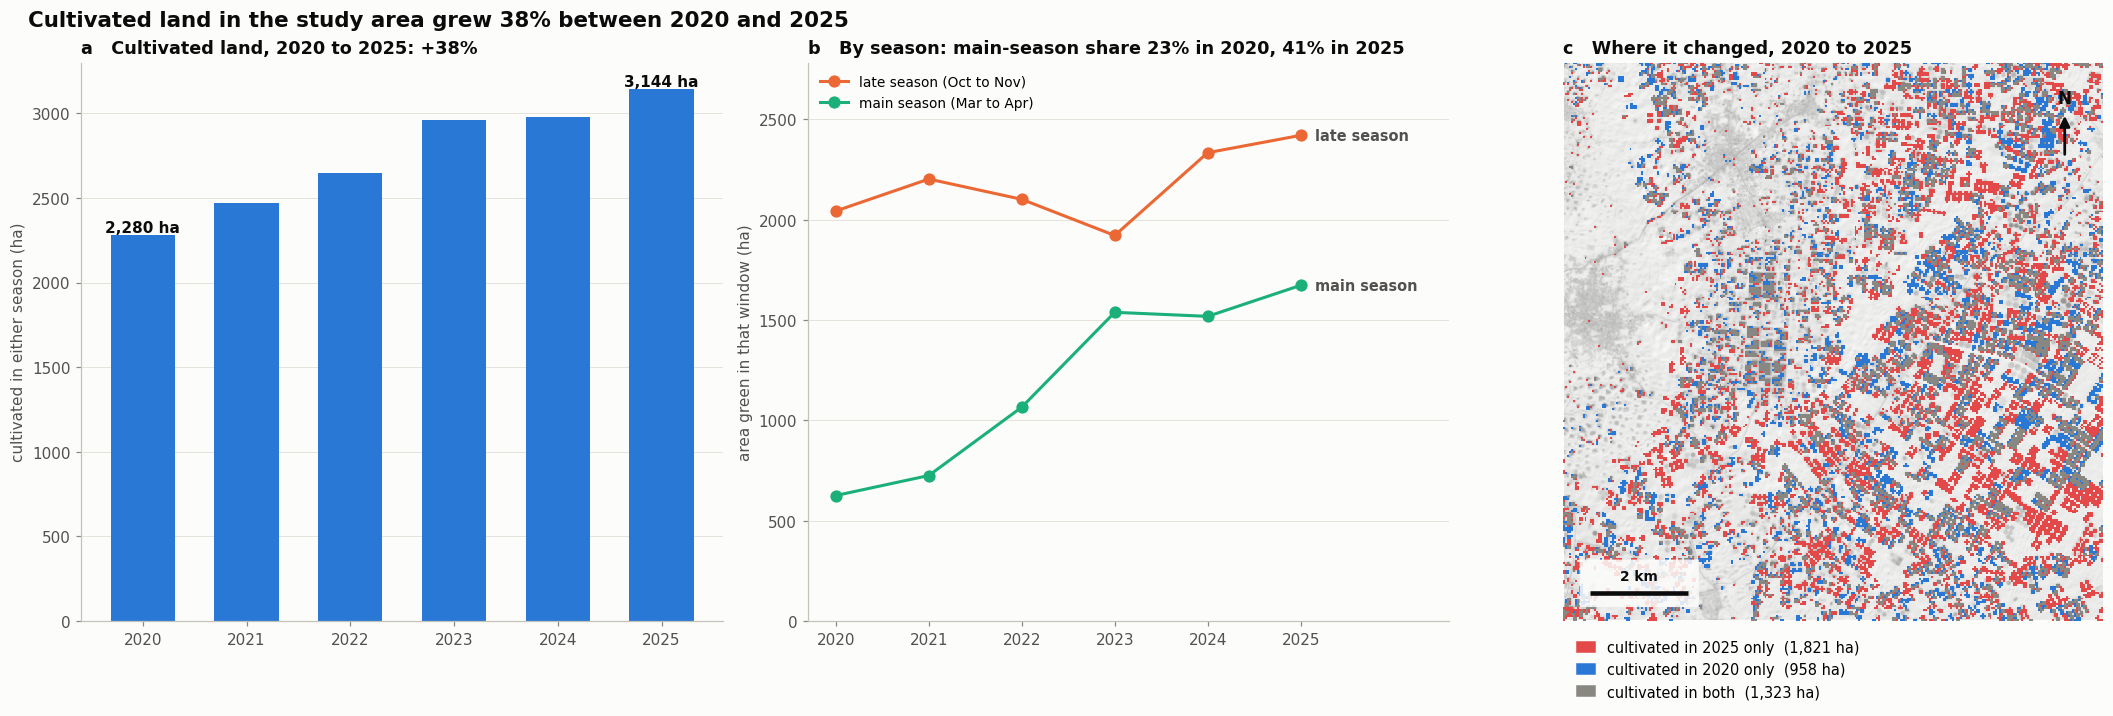

In [14]:
def window_ndvi(start, end):
    found = search_items(f"{start}/{end}")
    layers, xy = [], None
    for off in (0, 1000):
        group = [it for it in found if offset_for(it) == off]
        if not group:
            continue
        d = load(group, bands=["B04", "B08", "SCL"], bbox=BBOX, resolution=EXPANSION_RES,
                 crs=EPSG, groupby="solar_day", pool=4)
        ok = ~d.SCL.isin(BAD_SCL)
        r = (d.B04.astype("float32") - off) / 10000
        n = (d.B08.astype("float32") - off) / 10000
        r, n = r.where((r > 0) & (r < 1.2) & ok), n.where((n > 0) & (n < 1.2) & ok)
        v = ((n - r) / (n + r)).where(lambda x: (x > -1) & (x < 1))
        layers.append(v.quantile(0.9, dim="time", skipna=True).values)
        xy = (d.x.values, d.y.values)
    if not layers:
        return None, 0, None
    return np.fmax.reduce(np.stack(layers), axis=0), len(found), xy

windows, n_scenes = {}, {}
if RUN_EXPANSION:
    for y in EXPANSION_YEARS:
        try:
            late, n1, xy = window_ndvi(f"{y-1}-10-01", f"{y-1}-11-30")
            main, n2, _ = window_ndvi(f"{y}-03-01", f"{y}-04-30")
            if late is None or main is None:
                print(f"{y}: a window has no scenes; skipped")
                continue
            windows[y], n_scenes[y], exp_xy = (late, main), (n1, n2), xy
            print(f"{y}: late-season window {n1} scenes, main-season window {n2} scenes")
        except Exception as e:
            print(f"{y}: skipped ({type(e).__name__}: {e})")

if len(windows) >= 2:
    years = sorted(windows)
    common = np.all(np.stack([~np.isnan(w) for y in years for w in windows[y]]), axis=0)
    px_ha = EXPANSION_RES ** 2 / 1e4
    cult = {y: {"late": (windows[y][0] > NDVI_FIELD_THRESHOLD) & common,
                "main": (windows[y][1] > NDVI_FIELD_THRESHOLD) & common} for y in years}
    area = pd.DataFrame({y: {"late": cult[y]["late"].sum() * px_ha, "main": cult[y]["main"].sum() * px_ha,
                             "either": (cult[y]["late"] | cult[y]["main"]).sum() * px_ha} for y in years}).T
    y0, y1 = years[0], years[-1]
    GROWTH = (float(100 * (area.either[y1] - area.either[y0]) / area.either[y0])
              if area.either[y0] > 0 else float("nan"))
    tot0, tot1 = area.late[y0] + area.main[y0], area.late[y1] + area.main[y1]
    MAIN_SHARE0 = float(area.main[y0] / tot0) if tot0 > 0 else float("nan")
    MAIN_SHARE1 = float(area.main[y1] / tot1) if tot1 > 0 else float("nan")
    print(area.round(0).to_string())
    print(f"\ncultivated in either season: {area.either[y0]:,.0f} ha in {y0} -> {area.either[y1]:,.0f} ha "
          f"in {y1} ({GROWTH:+.0f}%)")
    print(f"pixels with clear observations in every window: {common.mean():.0%}")

    a0 = cult[y0]["late"] | cult[y0]["main"]
    a1 = cult[y1]["late"] | cult[y1]["main"]
    change = np.full(a0.shape, np.nan)
    change[a0 & a1], change[a1 & ~a0], change[a0 & ~a1] = 0, 1, 2
    ha = {k: float((change == k).sum() * px_ha) for k in (0, 1, 2)}
    hx = EXPANSION_RES / 2
    EXT2 = [exp_xy[0].min() - hx, exp_xy[0].max() + hx, exp_xy[1].min() - hx, exp_xy[1].max() + hx]
    OR2 = "upper" if exp_xy[1][0] > exp_xy[1][-1] else "lower"

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6.4), constrained_layout=True,
                                        gridspec_kw={"width_ratios": [1, 1, 1.15]})
    ax1.bar([str(y) for y in years], area.either.values, color=C_STABLE, width=0.62)
    for y in (y0, y1):
        ax1.text(str(y), area.either[y], f"{area.either[y]:,.0f} ha", ha="center", va="bottom",
                 color=INK, fontsize=10, fontweight="bold")
    ax1.set_ylabel("cultivated in either season (ha)")
    ax1.set_title(f"a   Cultivated land, {y0} to {y1}: {GROWTH:+.0f}%")
    ax1.grid(axis="x", visible=False)

    for key, col, name in (("late", C_PRIORITY, "late season (Oct to Nov)"),
                           ("main", C_NORMAL, "main season (Mar to Apr)")):
        ax2.plot([str(y) for y in years], area[key].values, color=col, marker="o", ms=7, label=name)
        ax2.text(len(years) - 0.85, area[key].values[-1], name.split(" (")[0], color=INK_2,
                 fontsize=9.5, fontweight="bold", va="center")
    ax2.set_ylim(0, area[["late", "main"]].values.max() * 1.15)
    ax2.set_xlim(-0.3, len(years) + 0.6)
    ax2.set_ylabel("area green in that window (ha)")
    ax2.set_title(f"b   By season: main-season share {MAIN_SHARE0:.0%} in {y0}, {MAIN_SHARE1:.0%} in {y1}")
    ax2.legend(loc="upper left", fontsize=9); ax2.grid(axis="x", visible=False)

    ax3.imshow(gray, extent=EXTENT, origin=ORIGIN, cmap="Greys_r", vmin=0, vmax=1, alpha=0.40)
    ax3.imshow(change, extent=EXT2, origin=OR2, cmap=ListedColormap([C_KEPT, C_GAIN, C_LOSS]),
               vmin=-0.5, vmax=2.5, interpolation="nearest")
    map_axes(ax3); scalebar(ax3, EXT2); north_arrow(ax3, EXT2)
    ax3.set_title(f"c   Where it changed, {y0} to {y1}")
    ax3.legend(handles=[mpatches.Patch(color=C_GAIN, label=f"cultivated in {y1} only  ({ha[1]:,.0f} ha)"),
                        mpatches.Patch(color=C_LOSS, label=f"cultivated in {y0} only  ({ha[2]:,.0f} ha)"),
                        mpatches.Patch(color=C_KEPT, label=f"cultivated in both  ({ha[0]:,.0f} ha)")],
               loc="upper left", bbox_to_anchor=(0, -0.01), fontsize=9.5, handlelength=1.3)
    trend = "grew" if GROWTH > 0 else "shrank"
    fig.suptitle(f"Cultivated land in the study area {trend} {abs(GROWTH):.0f}% between {y0} and {y1}"
                 if np.isfinite(GROWTH) else f"Cultivated land in the study area, {y0} to {y1}",
                 x=0.01, ha="left", fontsize=14, fontweight="bold", color=INK)
    fig.savefig("fig4_cultivated_land.png"); plt.show()
else:
    GROWTH = MAIN_SHARE0 = MAIN_SHARE1 = float("nan")
    print("Cultivated-land analysis skipped: fewer than two usable years.")

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
14. Key Numbers
</h2>
</div>
Every number quoted in the README and the slides comes from this cell.

In [15]:
import json

def num(x, nd=1):
    return None if x is None or (isinstance(x, float) and np.isnan(x)) else round(float(x), nd)

def pv(x):
    return None if x is None or np.isnan(x) else float(x)

summary = {
    "scenes": len(items),
    "observation_dates": int(ds.sizes["time"]),
    "plots_detected": int(n_found),
    "plots_largest_considered": int(len(field_ids)),
    "full_cycle_observed": int(full_cycle.sum()),
    "perennial_or_stable": int((category == CATS[0]).sum()),
    "normal_crop_cycle": int((category == CATS[2]).sum()),
    "priority_season_ended_early": int((category == CATS[1]).sum()),
    "not_assessable": int((category == CATS[3]).sum()),
    "median_season_days_normal": num(phen.loc[category == CATS[2], "season_days"].median()),
    "median_season_days_priority": num(phen.loc[category == CATS[1], "season_days"].median()),
    "median_shortfall_days_priority": num(phen.loc[category == CATS[1], "shortfall_days"].median()),
    "lead_plots_analysed": int(len(lead)),
    "lead_median_all_days": num(LEAD_ALL),
    "lead_median_priority_days": num(LEAD_PRI),
    "lead_median_normal_days": num(LEAD_NOR),
    "lead_share_water_first": num(LEAD_SHARE, 3),
    "lead_wilcoxon_p": pv(P_ALL),
    "lead_group_mannwhitney_p": pv(P_GROUP),
    "lead_group_scaled_by_decline_speed_p": pv(P_GROUP_REL),
    "decline_days_priority": num(DECL_PRI),
    "decline_days_normal": num(DECL_NOR),
    "warning_gain_days": num(GAIN_DAYS),
    "alarm_before_decline_greenness_days": num(LEAD_G),
    "alarm_before_decline_beyond_green_days": num(LEAD_B),
    "caught_greenness_share": num(CAUGHT_G, 3),
    "caught_beyond_green_share": num(CAUGHT_B, 3),
    "alarms_on_normal_or_perennial_greenness": FA_G,
    "alarms_on_normal_or_perennial_beyond_green": FA_B,
    "cultivated_growth_percent": num(GROWTH),
    "main_season_share_first_year": num(MAIN_SHARE0, 3),
    "main_season_share_last_year": num(MAIN_SHARE1, 3),
}
with open("results_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
for k, v in summary.items():
    print(f"{k:45s} {v}")

scenes                                        503
observation_dates                             116
plots_detected                                3050
plots_largest_considered                      400
full_cycle_observed                           380
perennial_or_stable                           6
normal_crop_cycle                             356
priority_season_ended_early                   23
not_assessable                                15
median_season_days_normal                     83.5
median_season_days_priority                   58.0
median_shortfall_days_priority                36.0
lead_plots_analysed                           340
lead_median_all_days                          3.1
lead_median_priority_days                     0.5
lead_median_normal_days                       3.3
lead_share_water_first                        0.803
lead_wilcoxon_p                               2.086676166476353e-27
lead_group_mannwhitney_p                      0.9999974267231316
lead_group_scal

<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
15. Record the Exact Environment
</h2>
</div>
This writes the versions actually used in this run to `requirements_used.txt`, so the results can be reproduced.

In [16]:
import importlib.metadata as im, sys
pkgs = ["pystac-client", "planetary-computer", "odc-stac", "odc-geo", "xarray", "numpy",
        "pandas", "scipy", "matplotlib", "rasterio"]
lines = []
for p in pkgs:
    try:
        lines.append(f"{p}=={im.version(p)}")
    except im.PackageNotFoundError:
        pass
with open("requirements_used.txt", "w") as f:
    f.write("\n".join(lines) + "\n")
print(f"python {sys.version.split()[0]}")
print("\n".join(lines))

python 3.13.15
pystac-client==0.9.0
planetary-computer==1.0.0
odc-stac==0.5.3
odc-geo==0.5.3
xarray==2025.12.0
numpy==2.1.3
pandas==2.2.3
scipy==1.16.3
matplotlib==3.10.0
rasterio==1.5.2


<div style="margin: 50px 0 30px 0;">
<h2 style="color: inherit; font-size: 1.6em; font-weight: 400; font-family: 'Playfair Display', Georgia, serif; letter-spacing: 0.5px; border-bottom: 2px solid #056587; padding-bottom: 12px; display: inline-block;">
16. Validation and Limitations
</h2>
</div>

**There is no ground truth for this season.** Nothing here has been checked against observed crop condition in the
field. The outputs are screening indicators that rank plots for human inspection, not diagnoses, and the priority
list is unverified.

**What is verified:** the reflectance offset is removed only from scenes that carry it, checked scene by scene from
the processing baseline (Planetary Computer serves ESA's numbers unchanged); index values lie in their physically
valid ranges (printed in section 5); the failure test
compares each crop only with crops that emerged in the same weeks, so the two crop calendars of El Oued do not
contaminate each other (shown in the decision-rule figure); the early-warning replay uses only past observations of
each index at every date.

**Known-answer test.** The same code was also run on a synthetic oasis with known behaviours (both calendars, double cropping, failing crops, palm groves, clouds), provided in the `tests/` folder of the repository. It flagged 44 of 48 failing crops and none of the 208 normal or double-cropped ones, and it recovered a stress-specific leaf-water lead planted in the data. The negative result of Figure 2 is therefore a property of the data, not a blind test.

**Proper validation would require** agronomist visits to a sample of priority and normal plots in the same season,
or recorded yield per plot. That is the first thing we would do with more time and local access.

**A short season is not a cause.** A green season that ends early is consistent with water stress, nutrient
deficiency, disease, frost, or a deliberate early harvest for market timing. A larger leaf-water lead on failing
crops is *consistent with* water stress, but NDMI also responds to canopy cover, so it is not proof. Separating
water stress from nutrient deficiency needs narrow spectral bands, near 970 and 1200 nm for water and across the
red edge for chlorophyll and nitrogen, which a hyperspectral sensor such as EMIT or EnMAP provides and Sentinel-2
cannot. That is the natural next step.

**Mixed pixels.** Plots are small relative to the 20 m pixel, so most pixels combine canopy with bare sand. This
lowers absolute NDVI.

**Thresholds are reasoned, not calibrated.** Detection (0.30), minimum peak (0.25), minimum amplitude (0.15), cohort
window (20 days) and shortfall (25 days) were chosen as sensible values for a screening tool. A sensitivity analysis
has not been performed.

**Cohorts assume similar crops.** Two crops that emerge in the same weeks may still be different species with
different normal season lengths. Where the oasis mixes crops within one calendar, some flags will reflect crop type
rather than failure.

**Double cropping.** Where a pivot carries two crops in one year, only the cycle containing the yearly peak is
analysed.

**Cultivated-land figures** compare two seasonal windows between years. Rotation and fallowing mean that "cultivated
in one year only" includes pivots resting that year, not only land brought into or taken out of agriculture.

### Data

| Product | Provider | Period | Processing | Licence |
|---|---|---|---|---|
| Sentinel-2 MSI Level-2A | ESA Copernicus, via Microsoft Planetary Computer | Aug 2022 to Jul 2023; Oct-Nov and Mar-Apr windows 2019 to 2025 | surface reflectance | free and open (Copernicus) |

No commercial or restricted imagery is used or redistributed.